# PRICE PREDICTION PROJECT PRESENTATION

###  IMPORTING  LIBRARIES AND DATASET

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\user\Desktop\NELSONWORK STATION\PHONE PREDICTION.csv")
df

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.20,424,8,1.350,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.00,233,2,1.300,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.70,312,4,1.200,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.00,233,2,1.300,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.00,233,2,1.300,4.0,1.000,3.15,0.0,1700,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,1206,3551,4638,178.0,5.46,538,4,1.875,128.0,6.000,12.00,16.0,4080,8.4
157,1296,3211,8016,170.0,5.50,534,4,1.975,128.0,6.000,20.00,8.0,3400,7.9
158,856,3260,8809,150.0,5.50,401,8,2.200,64.0,4.000,20.00,20.0,3000,6.8
159,1296,3211,8946,170.0,5.50,534,4,1.975,128.0,6.000,20.00,8.0,3400,7.9


#  DATA EXPLORING TO UNDERSTAND ITS STRUCTURE

 ### CHECK NUMBER OF ROWS/COLUMNS
 ### DATA TYPES
 ### STATISTIC

In [4]:
df.shape

(161, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


In [100]:
df.describe()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,675.559006,2215.596273,621.465839,170.426087,5.209938,335.055901,4.857143,1.502832,24.501714,2.204994,10.378261,4.503106,2842.111801,8.921739
std,410.851583,768.187171,1546.618517,92.888612,1.509953,134.826659,2.444016,0.599783,28.804773,1.609831,6.181585,4.342053,1366.990838,2.192564
min,10.000000,614.000000,10.000000,66.000000,1.400000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000
25%,237.000000,1734.000000,37.000000,134.100000,4.800000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,774.000000,2258.000000,106.000000,153.000000,5.150000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,1026.000000,2744.000000,382.000000,170.000000,5.500000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,1339.000000,4361.000000,9807.000000,753.000000,12.200000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


#  DATA CLEANING 

In [96]:
df.isnull().sum()

Product_id      0
Price           0
Sale            0
weight          0
resoloution     0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64

In [97]:
df.duplicated().sum()

np.int64(0)

### Checking  Outliers Manually To See The Results Of The Outliers If Its An Error Or An Extreme
* USING B0XPLOT
* AND IQR METHOD

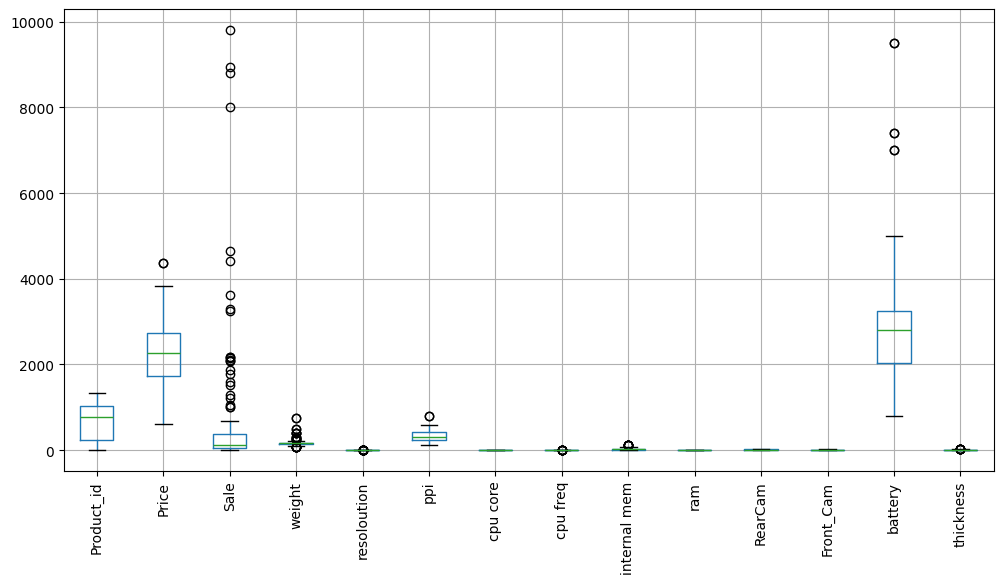

In [6]:
df.boxplot(figsize = (12,6))
plt.xticks(rotation=90)
plt.show()

In [ ]:
# a loop on all numeric columns using IQR

In [7]:
nums_cols = df.select_dtypes(include = np.number).columns

for col in nums_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    print(col, len(df[(df[col] < lower) | (df[col] > upper)]))

Product_id 0
Price 2
Sale 24
weight 24
resoloution 26
ppi 2
cpu core 0
cpu freq 10
internal mem 8
ram 0
RearCam 0
Front_Cam 0
battery 6
thickness 8


# PRICE

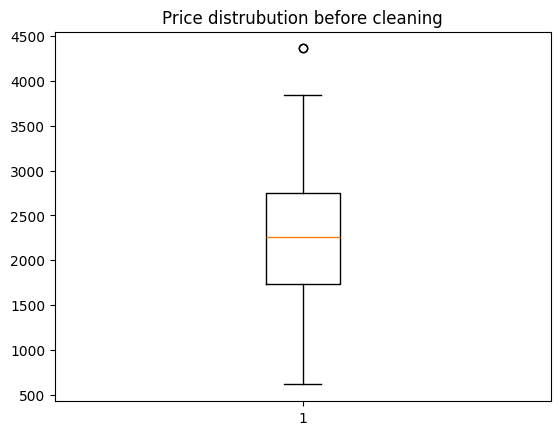

In [8]:
plt.boxplot(df['Price'])
plt.title('Price distrubution before cleaning')
plt.show()

In [50]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
    
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
    
price_outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]
price_outliers

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
152,290,4361,3248,238.0,5.7,515,8,1.95,128.0,6.0,12.0,8.0,7000,7.4
153,290,4361,3291,238.0,5.7,515,8,1.95,128.0,6.0,12.0,8.0,7000,7.4


# THICKNESS

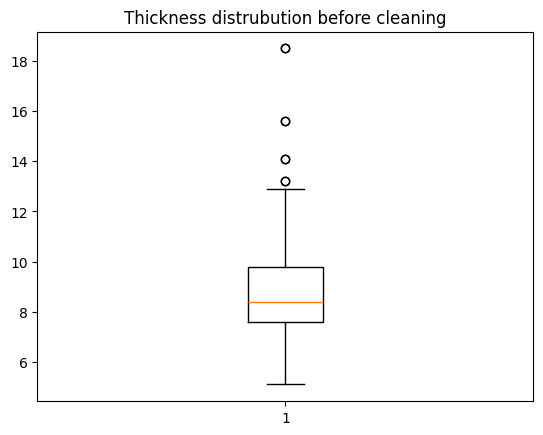

In [76]:
plt.boxplot(df['thickness'])
plt.title('Thickness distrubution before cleaning')
plt.show()

In [77]:
Q1 = df['thickness'].quantile(0.25)
Q3 = df['thickness'].quantile(0.75)
IQR = Q3 - Q1
    
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
    
thickness_outliers = df[(df['thickness'] < lower) | (df['thickness'] > upper)]
thickness_outliers

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
81,1026,791,106,66.0,1.5,121,1,0.208,0.000,0.004,0.0,0.0,800,13.2
86,1026,791,114,66.0,1.5,121,1,0.208,0.000,0.004,0.0,0.0,800,13.2
125,1198,705,423,110.0,2.2,128,0,0.000,0.128,0.032,2.0,0.0,900,15.6
126,1198,705,427,110.0,2.2,128,0,0.000,0.128,0.032,2.0,0.0,900,15.6
140,701,628,1224,102.9,2.2,128,0,0.000,0.256,0.128,1.3,0.0,950,18.5
141,701,628,1274,102.9,2.2,128,0,0.000,0.256,0.128,1.3,0.0,950,18.5
149,826,614,2159,69.8,1.4,129,0,0.000,0.000,0.004,0.0,0.0,800,14.1
150,826,614,2171,69.8,1.4,129,0,0.000,0.000,0.004,0.0,0.0,800,14.1


# BATTERY

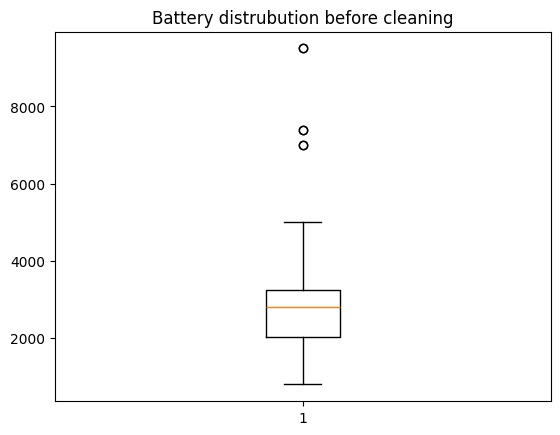

In [55]:
plt.boxplot(df['battery'])
plt.title('Battery distrubution before cleaning')
plt.show()

In [56]:
Q1 = df['battery'].quantile(0.25)
Q3 = df['battery'].quantile(0.75)
IQR = Q3 - Q1
    
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
    
battery_outliers = df[(df['battery'] < lower) | (df['battery'] > upper)]
battery_outliers

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
37,662,2124,35,489.0,10.1,224,4,2.26,16.0,2.0,5.0,2.0,7400,7.8
40,662,2124,37,489.0,10.1,224,4,2.26,16.0,2.0,5.0,2.0,7400,7.8
127,1112,2491,455,753.0,12.2,247,8,1.60,32.0,3.0,8.0,2.0,9500,8.0
128,1112,2491,456,753.0,12.2,247,8,1.60,32.0,3.0,8.0,2.0,9500,8.0
152,290,4361,3248,238.0,5.7,515,8,1.95,128.0,6.0,12.0,8.0,7000,7.4
153,290,4361,3291,238.0,5.7,515,8,1.95,128.0,6.0,12.0,8.0,7000,7.4


# INTERNAL MEMORY

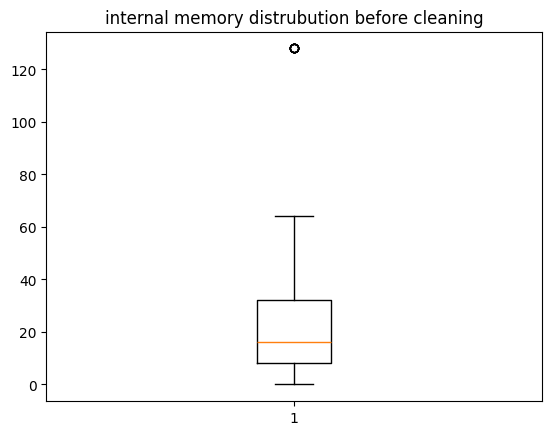

In [57]:
plt.boxplot(df['internal mem'])
plt.title('internal memory distrubution before cleaning')
plt.show()

In [58]:
Q1 = df['internal mem'].quantile(0.25)
Q3 = df['internal mem'].quantile(0.75)
IQR = Q3 - Q1
    
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
    
internal_outliers = df[(df['internal mem'] < lower) | (df['internal mem'] > upper)]

internal_outliers

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
83,1216,3837,111,167.8,5.43,541,4,1.875,128.0,6.0,16.0,8.0,3600,7.6
87,1216,3837,119,167.8,5.43,541,4,1.875,128.0,6.0,16.0,8.0,3600,7.6
152,290,4361,3248,238.0,5.70,515,8,1.950,128.0,6.0,12.0,8.0,7000,7.4
153,290,4361,3291,238.0,5.70,515,8,1.950,128.0,6.0,12.0,8.0,7000,7.4
155,1206,3551,4408,178.0,5.46,538,4,1.875,128.0,6.0,12.0,16.0,4080,8.4
156,1206,3551,4638,178.0,5.46,538,4,1.875,128.0,6.0,12.0,16.0,4080,8.4
157,1296,3211,8016,170.0,5.50,534,4,1.975,128.0,6.0,20.0,8.0,3400,7.9
159,1296,3211,8946,170.0,5.50,534,4,1.975,128.0,6.0,20.0,8.0,3400,7.9


# PPI 

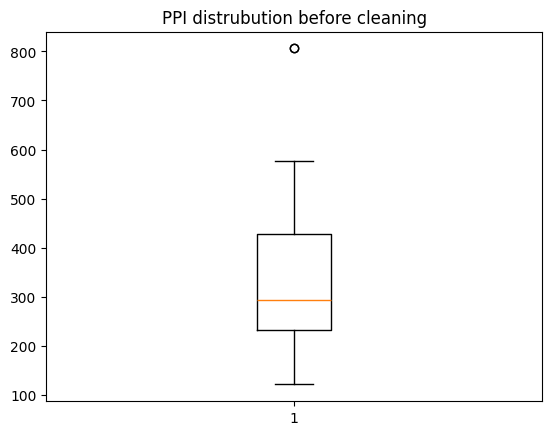

In [61]:
plt.boxplot(df['ppi'])
plt.title('PPI distrubution before cleaning')
plt.show()

In [62]:
Q1 = df['ppi'].quantile(0.25)
Q3 = df['ppi'].quantile(0.75)
IQR = Q3 - Q1
    
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
    
ppi_outliers = df[(df['ppi'] < lower) | (df['ppi'] > upper)]
ppi_outliers

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
146,1137,3102,2071,180.0,5.5,806,8,1.75,32.0,3.0,23.0,5.1,3430,7.8
147,1137,3102,2088,180.0,5.5,806,8,1.75,32.0,3.0,23.0,5.1,3430,7.8


# CPU FREQUENCY

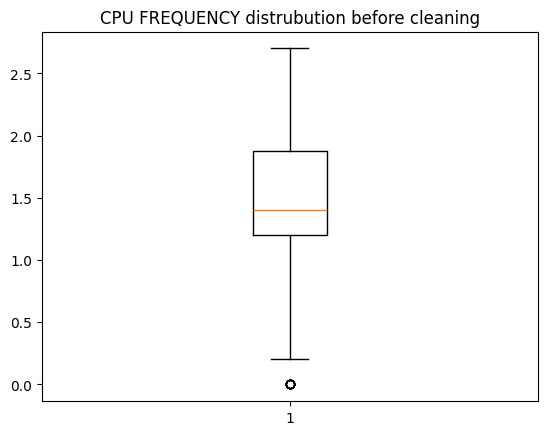

In [78]:
plt.boxplot(df['cpu freq'])
plt.title('CPU FREQUENCY distrubution before cleaning')
plt.show()

In [79]:
Q1 = df['cpu freq'].quantile(0.25)
Q3 = df['cpu freq'].quantile(0.75)
IQR = Q3 - Q1
    
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
    
cpu_outliers = df[(df['cpu freq'] < lower) | (df['cpu freq'] > upper)]
cpu_outliers

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
101,827,833,201,78.4,2.4,166,0,0.0,0.000,0.008,0.0,0.0,1100,12.9
105,827,833,213,78.4,2.4,166,0,0.0,0.000,0.008,0.0,0.0,1100,12.9
110,64,754,299,77.9,2.4,167,0,0.0,0.004,0.004,0.0,0.0,850,12.4
113,64,754,308,77.9,2.4,167,0,0.0,0.004,0.004,0.0,0.0,850,12.4
125,1198,705,423,110.0,2.2,128,0,0.0,0.128,0.032,2.0,0.0,900,15.6
126,1198,705,427,110.0,2.2,128,0,0.0,0.128,0.032,2.0,0.0,900,15.6
140,701,628,1224,102.9,2.2,128,0,0.0,0.256,0.128,1.3,0.0,950,18.5
141,701,628,1274,102.9,2.2,128,0,0.0,0.256,0.128,1.3,0.0,950,18.5
149,826,614,2159,69.8,1.4,129,0,0.0,0.000,0.004,0.0,0.0,800,14.1
150,826,614,2171,69.8,1.4,129,0,0.0,0.000,0.004,0.0,0.0,800,14.1


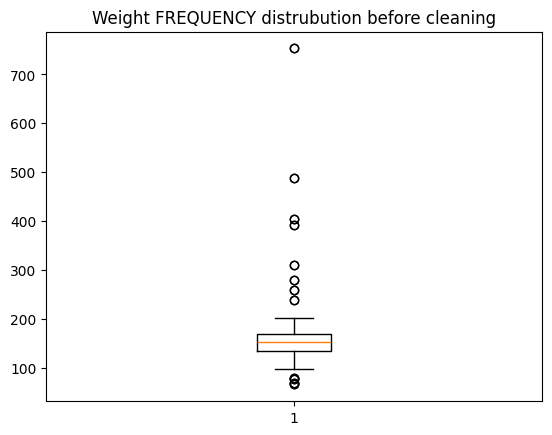

In [80]:
plt.boxplot(df['weight'])
plt.title('Weight FREQUENCY distrubution before cleaning')
plt.show()

In [81]:
Q1 = df['cpu freq'].quantile(0.25)
Q3 = df['cpu freq'].quantile(0.75)
IQR = Q3 - Q1
    
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
    
cpu_outliers = df[(df['cpu freq'] < lower) | (df['cpu freq'] > upper)]
cpu_outliers

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
101,827,833,201,78.4,2.4,166,0,0.0,0.000,0.008,0.0,0.0,1100,12.9
105,827,833,213,78.4,2.4,166,0,0.0,0.000,0.008,0.0,0.0,1100,12.9
110,64,754,299,77.9,2.4,167,0,0.0,0.004,0.004,0.0,0.0,850,12.4
113,64,754,308,77.9,2.4,167,0,0.0,0.004,0.004,0.0,0.0,850,12.4
125,1198,705,423,110.0,2.2,128,0,0.0,0.128,0.032,2.0,0.0,900,15.6
126,1198,705,427,110.0,2.2,128,0,0.0,0.128,0.032,2.0,0.0,900,15.6
140,701,628,1224,102.9,2.2,128,0,0.0,0.256,0.128,1.3,0.0,950,18.5
141,701,628,1274,102.9,2.2,128,0,0.0,0.256,0.128,1.3,0.0,950,18.5
149,826,614,2159,69.8,1.4,129,0,0.0,0.000,0.004,0.0,0.0,800,14.1
150,826,614,2171,69.8,1.4,129,0,0.0,0.000,0.004,0.0,0.0,800,14.1


# RESOLUTION

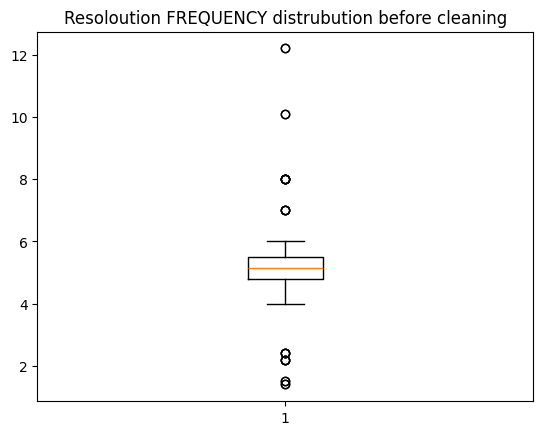

In [103]:
plt.boxplot(df['resoloution'])
plt.title('Resoloution FREQUENCY distrubution before cleaning')
plt.show()

In [104]:
Q1 = df['cpu freq'].quantile(0.25)
Q3 = df['cpu freq'].quantile(0.75)
IQR = Q3 - Q1
    
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
    
cpu_outliers = df[(df['cpu freq'] < lower) | (df['cpu freq'] > upper)]
cpu_outliers

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
101,827,833,201,78.4,2.4,166,0,0.0,0.000,0.008,0.0,0.0,1100,12.9
105,827,833,213,78.4,2.4,166,0,0.0,0.000,0.008,0.0,0.0,1100,12.9
110,64,754,299,77.9,2.4,167,0,0.0,0.004,0.004,0.0,0.0,850,12.4
113,64,754,308,77.9,2.4,167,0,0.0,0.004,0.004,0.0,0.0,850,12.4
125,1198,705,423,110.0,2.2,128,0,0.0,0.128,0.032,2.0,0.0,900,15.6
126,1198,705,427,110.0,2.2,128,0,0.0,0.128,0.032,2.0,0.0,900,15.6
140,701,628,1224,102.9,2.2,128,0,0.0,0.256,0.128,1.3,0.0,950,18.5
141,701,628,1274,102.9,2.2,128,0,0.0,0.256,0.128,1.3,0.0,950,18.5
149,826,614,2159,69.8,1.4,129,0,0.0,0.000,0.004,0.0,0.0,800,14.1
150,826,614,2171,69.8,1.4,129,0,0.0,0.000,0.004,0.0,0.0,800,14.1


# Drop columns that doesnt influences price directly

In [3]:
df.drop(columns=['Product_id','Sale'],inplace=True) 
df

,Price,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,2357,135.0,5.20,424,8,1.350,16.0,3.000,13.00,8.0,2610,7.4
1,1749,125.0,4.00,233,2,1.300,4.0,1.000,3.15,0.0,1700,9.9
2,1916,110.0,4.70,312,4,1.200,8.0,1.500,13.00,5.0,2000,7.6
3,1315,118.5,4.00,233,2,1.300,4.0,0.512,3.15,0.0,1400,11.0
4,1749,125.0,4.00,233,2,1.300,4.0,1.000,3.15,0.0,1700,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...
156,3551,178.0,5.46,538,4,1.875,128.0,6.000,12.00,16.0,4080,8.4
157,3211,170.0,5.50,534,4,1.975,128.0,6.000,20.00,8.0,3400,7.9
158,3260,150.0,5.50,401,8,2.200,64.0,4.000,20.00,20.0,3000,6.8
159,3211,170.0,5.50,534,4,1.975,128.0,6.000,20.00,8.0,3400,7.9


# USING IQR I DROP ALL ERRORS VALUES IN EVERY NUMERIC COLUMNS

In [4]:
nums_cols = df.select_dtypes(include = np.number).columns

for col in nums_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]
df

,Price,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,2357,135.0,5.2,424,8,1.35,16.0,3.0,13.0,8.0,2610,7.4
2,1916,110.0,4.7,312,4,1.20,8.0,1.5,13.0,5.0,2000,7.6
5,2137,150.0,5.5,401,4,2.30,16.0,2.0,16.0,8.0,2500,9.5
7,2137,150.0,5.5,401,4,2.30,16.0,2.0,16.0,8.0,2500,9.5
9,2580,145.0,5.1,432,4,2.50,16.0,2.0,16.0,2.0,2800,8.1
...,...,...,...,...,...,...,...,...,...,...,...,...
143,2508,152.0,5.2,424,4,2.50,16.0,3.0,20.7,2.2,3100,7.3
144,1921,179.0,6.0,184,4,1.30,8.0,1.0,13.0,8.0,2580,8.0
145,1921,179.0,6.0,184,4,1.30,8.0,1.0,13.0,8.0,2580,8.0
154,2536,202.0,6.0,367,8,1.50,16.0,3.0,21.5,16.0,2700,8.4


In [65]:
df.shape

(90, 12)

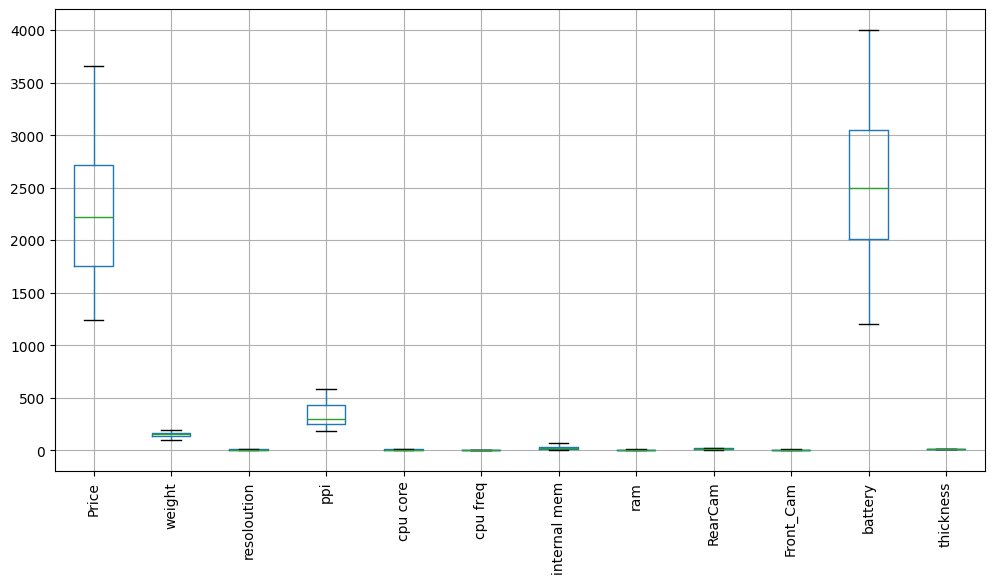

In [12]:
df.boxplot(figsize = (12,6))
plt.xticks(rotation=90)
plt.show()

In [5]:
nums_cols = df.select_dtypes(include = np.number).columns

for col in nums_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    print(col, len(df[(df[col] < lower) | (df[col] > upper)]))

Price 0
weight 0
resoloution 0
ppi 0
cpu core 0
cpu freq 0
internal mem 0
ram 0
RearCam 0
Front_Cam 0
battery 0
thickness 0


###  EDA(EXPLORATORY DATA ANALYSIS) USING FEATURES THAT INFLUENCES PRICE

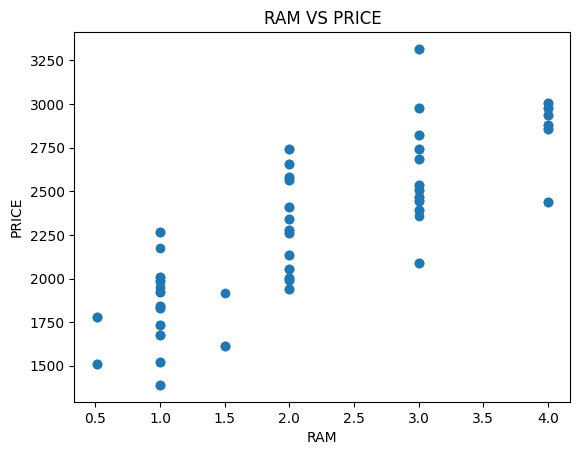

In [67]:
plt.scatter(df['ram'], df['Price'])
plt.xlabel('RAM')
plt.ylabel('PRICE')
plt.title("RAM VS PRICE")
plt.show()

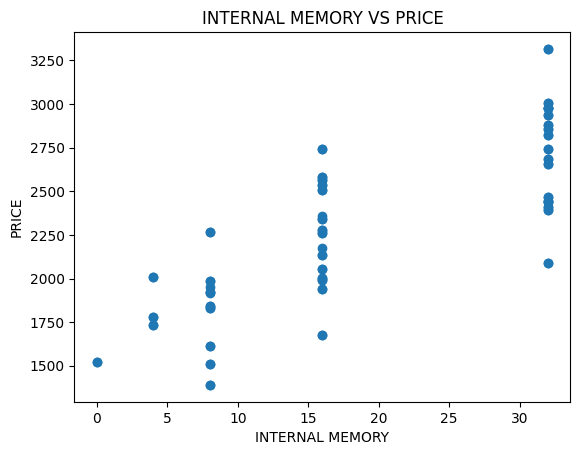

In [68]:
plt.scatter(df['internal mem'], df['Price'])
plt.xlabel('INTERNAL MEMORY')
plt.ylabel('PRICE')
plt.title("INTERNAL MEMORY VS PRICE")
plt.show()

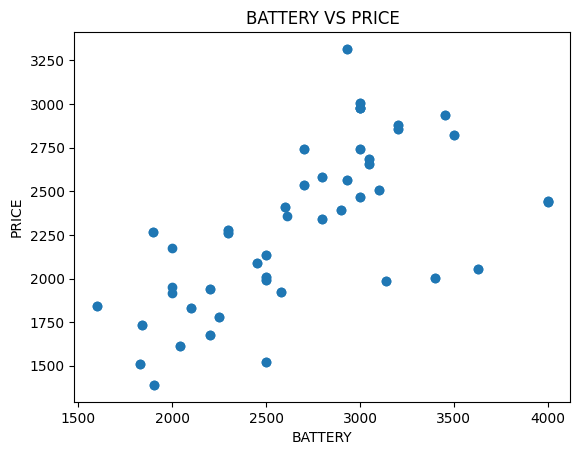

In [69]:
plt.scatter(df['battery'], df['Price'])
plt.xlabel('BATTERY')
plt.ylabel('PRICE')
plt.title("BATTERY VS PRICE")
plt.show()

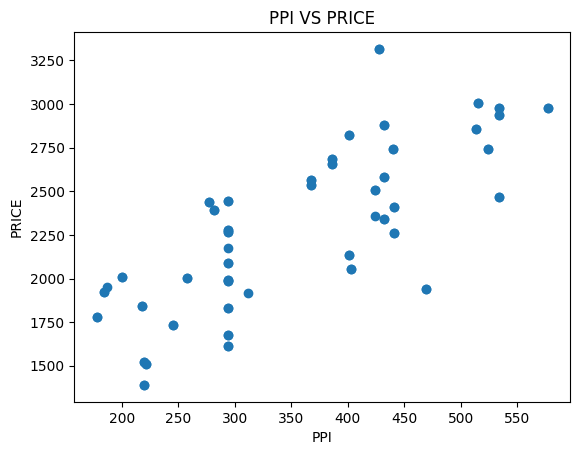

In [70]:
plt.scatter(df['ppi'], df['Price'])
plt.xlabel('PPI')
plt.ylabel('PRICE')
plt.title("PPI VS PRICE")
plt.show()

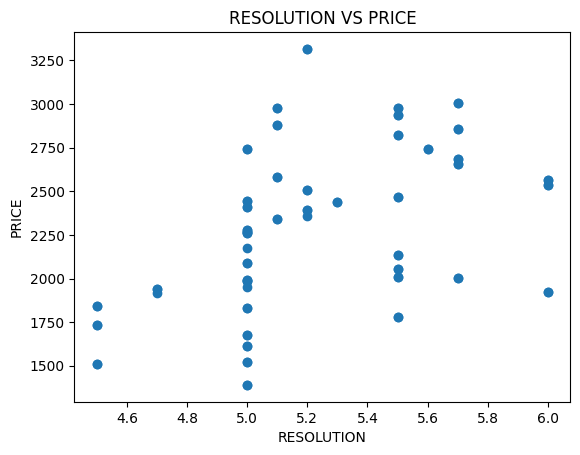

In [71]:
plt.scatter(df['resoloution'], df['Price'])
plt.xlabel('RESOLUTION')
plt.ylabel('PRICE')
plt.title("RESOLUTION VS PRICE")
plt.show()

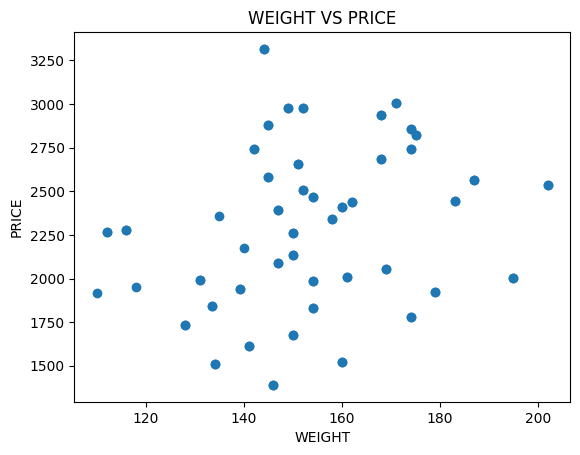

In [72]:
plt.scatter(df['weight'], df['Price'])
plt.xlabel('WEIGHT')
plt.ylabel('PRICE')
plt.title("WEIGHT VS PRICE")
plt.show()

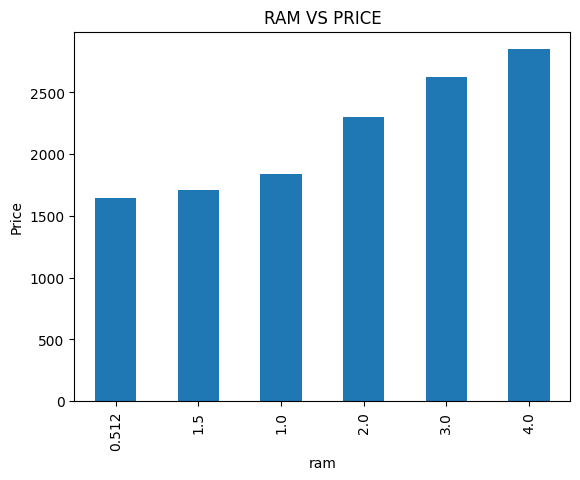

In [73]:
df.groupby('ram').Price.mean().sort_values().head(20).plot(kind = 'bar')
plt.ylabel("Price")
plt.title("RAM VS PRICE")
plt.show()

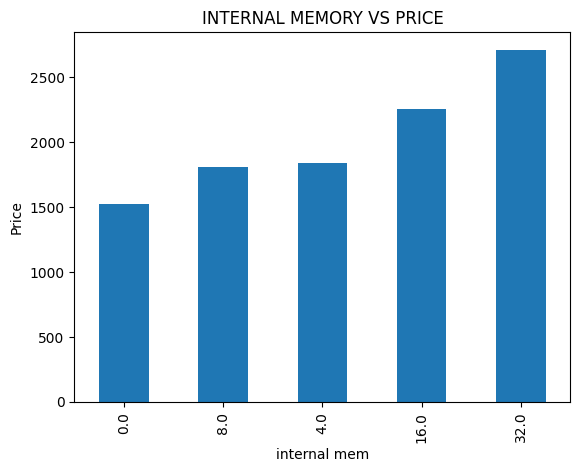

In [74]:
df.groupby('internal mem').Price.mean().sort_values().head(20).plot(kind = 'bar')
plt.ylabel("Price")
plt.title("INTERNAL MEMORY VS PRICE")
plt.show()

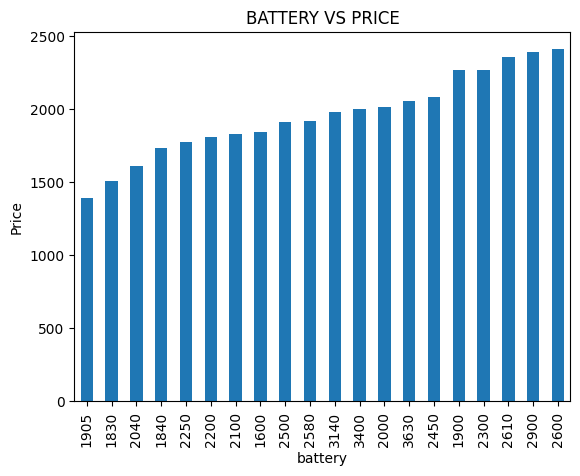

In [75]:
df.groupby('battery').Price.mean().sort_values().head(20).plot(kind = 'bar')
plt.ylabel("Price")
plt.title("BATTERY VS PRICE")
plt.show()

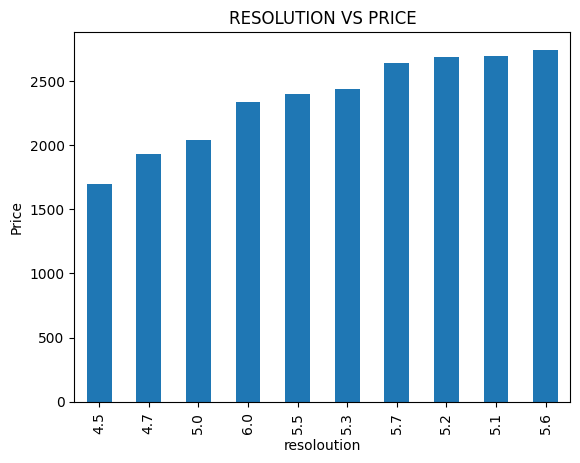

In [76]:
df.groupby('resoloution').Price.mean().sort_values().head(20).plot(kind = 'bar')
plt.ylabel("Price")
plt.title("RESOLUTION VS PRICE")
plt.show()

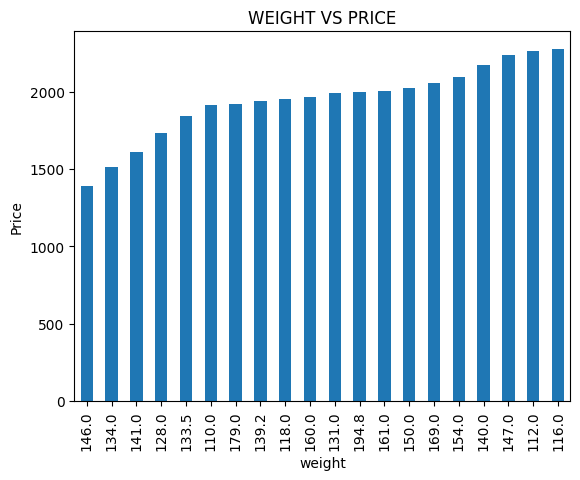

In [77]:
df.groupby('weight').Price.mean().sort_values().head(20).plot(kind = 'bar')
plt.ylabel("Price")
plt.title("WEIGHT VS PRICE")
plt.show()

#### I DID EDA ON SOME FEATURES TO UNDERSTAND THE DISTRIBUTION AND RELATIONSHIP WITH PRICE 
FROM THE ANALYSIS FEATURES LIKE RAM,INTERNAL MEMORY, BATTERY AND PPI SHOWS A STRONG RELASTIONSHIP 

# MACHINE LEARNING MODELS  USING 3 MODELS
* LINEAR REGRESSION
* DECISION TREE
* RANDOM FOREST

### IMPORTED MY LIBRARIES

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score 

In [8]:
x = df.drop("Price", axis = 1) # features
y = df["Price"] # target

# TRAIN-TEST SPLIT 

In [9]:
x_train , x_test , y_train , y_test = train_test_split(x , y , random_state=42 , test_size=0.2)

In [30]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(72, 11)
(18, 11)
(72,)
(18,)


# Linear Regression Model

In [11]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
# MODEL EVALUATION

y_pred = lr.predict(x_test)

In [31]:
r2 = r2_score(y_test , y_pred)
r2

0.8501677457563002

In [36]:
mae = mean_absolute_error(y_test , y_pred)
mae

160.14466055619954

In [33]:
rmse = np.sqrt(mean_squared_error(y_test , y_pred))
rmse

np.float64(197.7027085284015)

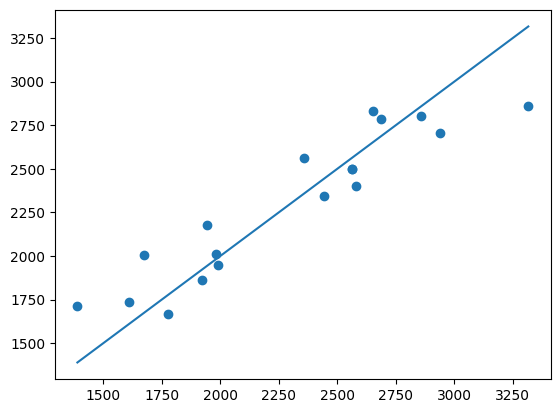

In [15]:
plt.scatter(y_test , y_pred)
plt.plot([min(y_test), max(y_test)],[min(y_test), max(y_test)])
plt.show()

# Decision Tree Model

In [34]:
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [28]:
y_pred_dt = dt.predict(x_test)

In [35]:
r2 = r2_score(y_test , y_pred_dt)
r2

0.9095881902096353

In [18]:
mae = mean_absolute_error(y_test , y_pred_dt)
mae

59.166666666666664

In [19]:
rmse = np.sqrt(mean_squared_error(y_test , y_pred_dt))
rmse

np.float64(153.57571422591528)

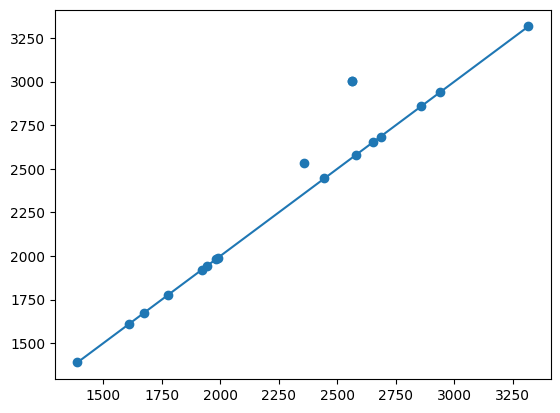

In [20]:
plt.scatter(y_test , y_pred_dt)
plt.plot([min(y_test), max(y_test)],[min(y_test), max(y_test)])
plt.show()

# Random Forest Model

In [21]:
rf = RandomForestRegressor()
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [22]:
y_pred_rf = rf.predict(x_test)

In [23]:
r2 = r2_score(y_test , y_pred_rf)
r2

0.9587627553771806

In [24]:
mae = mean_absolute_error(y_test , y_pred_rf)
mae

83.50277777777777

In [25]:
rmse = np.sqrt(mean_squared_error(y_test , y_pred_rf))
rmse

np.float64(103.7181548181845)

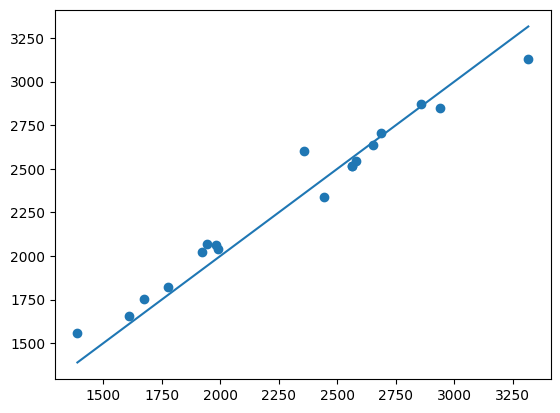

In [26]:
plt.scatter(y_test , y_pred_rf)
plt.plot([min(y_test), max(y_test)],[min(y_test), max(y_test)])
plt.show()

# in conclusion 
* Linear regression model perform moderately
* Decision tree model performance was good
* Random forest model perform the best overall

this model can be used for pricing new smartphones, market analysis and business decision making

In [151]:
df.to_csv("new_clean_cellphone.csv",index=False)